# The experiments, end to end

This notebook shows **the code that produced every number in the manuscript,
together with its output.**

### How to read it

| cells | outputs |
|---|---|
| §4–§5 — training and the comparator fit | **the verbatim stdout of the actual runs**, shipped unedited under `logs/`. Roughly 12 CPU-hours; not re-executed when this notebook is built. |
| §1–§3 — data build, the null, the model | the code path with **the values it produces**, taken from those same runs. Each is independently re-derivable from `results/`. |
| §6–§10 — aggregation, adjudication, figures | **executed when this notebook was written**, from the committed per-fold results. A few seconds. |

Nothing here needs MIMIC-IV access to *read*. Re-running §1–§5 does
(see `docs/REPRODUCE.md`). `verify.py` re-checks §6–§9 independently.

---

## 1. The cohort

`data.prep` applies the prespecified pruning to convergence: providers with
≥200 events, drugs with ≥200 events, provider×drug cells with ≥5 events.
`Not Given per Sliding Scale` is excluded from the primary outcome.

In [1]:
import sys; sys.path.insert(0, 'src')
import numpy as np, pandas as pd, data

e = data.frame()                 # MIMIC-IV emar + admissions/patients/dx/icu/transfers
d = data.prep(e)                 # codes, covariates, patient-disjoint folds

print(f"rows              {len(d['y']):,}")
print(f"providers         {int(d['n_nurse'])}")
print(f"drugs             {int(d['n_drug'])}")
print(f"non-administration rate  {float(d['y'].mean()):.5f}")
print(f"folds (patient-disjoint) {np.bincount(d['fold'])}")

rows              4,362,548
providers         936
drugs             522
non-administration rate  0.09285
folds (patient-disjoint) [869183 870947 867192 898456 856770]


## 2. The null — and the correction

Every reported quantity is a **net increment**: the observed gain minus the gain
obtained when provider identity is destroyed. The null therefore decides the answer.

Our first implementation was wrong. `nh[hadm] = nur` is a numpy fancy-index
assignment, which keeps only the **last** write per index, so every admission
collapsed to a single provider. The corrected design redraws each admission's
*k* distinct providers from the global pool with frequency weights and keeps the
within-admission assignment pattern.

In [2]:
print(data.shuffle_nurse.__doc__)

hadm, nur = d['hadm'], d['nur']
def diag(lab, name):
    g = pd.DataFrame({'h': hadm, 'n': lab}).groupby('h').n.nunique()
    c = np.bincount(lab, minlength=936); c = c[c > 0]
    print(f'{name:14} providers/admission mean {g.mean():.2f} median {g.median():.0f} '
          f'max {g.max():4d} | provider events median {np.median(c):6.0f} '
          f'max {c.max():7,} | unchanged {(lab == nur).mean():.4f}')

diag(nur, 'observed')
for k in (0, 1):
    diag(data.shuffle_nurse(d, k, 'A'), f'null A #{k}')

★귀무 — 제공자 «정체성»만 파괴하고 설계 구조는 보존한다.

    구판(v1)은 `nh[hadm] = nur` 의 팬시 인덱싱 때문에 입원마다 «마지막 한 명»만
    남아, 158,422개 입원 전부가 제공자 1명으로 접혔다. 실제 자료는 입원당
    평균 3.02명(중앙 2, 최대 635)이고 행의 90.7%가 다제공자 입원에 속한다.
    구판은 다른 귀무였다.

    design='A' (주판) 입원별 «제공자 라벨 재배정»
        각 입원의 서로 다른 제공자 k명을 전역 제공자 풀에서 빈도 가중으로
        비복원 추출한 k명으로 «갈아끼운다». 어느 행이 그중 누구에게 가는지의
        패턴(다중도)은 그대로 둔다.
        보존 : 입원당 행 수 · 입원당 제공자 수 · 입원 내 배정 패턴 · 제공자 빈도 분포
        파괴 : 제공자–환자/약물 결합

    design='B' (민감도) 크기 층화 «입원 블록» 교환
        (행 수, 제공자 수)가 같은 입원끼리 배정 벡터를 통째로 교환한다.
        구조를 «정확히» 보존하나 층이 작으면 교환 상대가 없다(그런 입원은 유지).
    

observed       providers/admission mean 3.02 median 2 max  635 | provider events median   2654 max  46,637 | unchanged 1.0000
null A #0      providers/admission mean 3.02 median 2 max  635 | provider events median   2754 max  42,465 | unchanged 0.0026
null A #1      providers/admission mean 3.02 median 2 max  635 | provider events median   2724 max  42,833 | unchanged 0.0025


For contrast, this is what the broken null produced. It is kept in the
repository under `results/fold_json_v1_broken_null/` because the manuscript
reports the correction.

In [3]:
# the superseded implementation, for the record
def shuffle_v1_broken(d, k):
    nh = np.zeros(d['hadm'].max() + 1, dtype=np.int64)
    nh[d['hadm']] = d['nur']                       # only the LAST write survives
    return np.random.default_rng(70 + k).permutation(nh)[d['hadm']]

diag(shuffle_v1_broken(d, 0), 'null v1')

null v1        providers/admission mean 1.00 median 1 max    1 | provider events median   2505 max 182,967 | unchanged 0.0020


## 3. The model

Two trainable latent tables (providers 936×64, drugs 522×64). Training alternates
**turns**: on a provider turn the drug table is frozen and only the provider table
is updated; on a drug turn the reverse. The partner table is synchronised at the
start of each turn.

`A` and `B` also carry the drug latent — without that alignment `C − B` mixes the
provider latent with extra drug-side capacity (§4.5 of the manuscript).

In [4]:
import cdld_core as CC
print(CC.__doc__)

sizes, ncov = list(d['sizes']), d['cov'].shape[1]
kw = dict(n_nurse=int(d['n_nurse']), n_drug=int(d['n_drug']))
mA = CC.Finder(sizes, ncov, n_drug=kw['n_drug'], drug_latent=True)
mB = CC.Finder(sizes, ncov, drug_latent=True, **kw)
mC = CC.Finder(sizes, ncov, latent=True, **kw)
for n, m in (('A', mA), ('B', mB), ('C', mC)):
    tot = sum(p.numel() for p in m.parameters())
    emb = sum(p.numel() for k_, p in m.named_parameters() if 'tab' in k_ or 'add' in k_)
    print(f'  {n}  parameters {tot:,}  (embedding tables {emb:,}, network {tot-emb:,})')

CDLD — Cyclic Dual Latent Discovery. 간호사 × 약물 투약 누락.

정본(`cdld_tutorial_fixed.ipynb` build_finder_model)의 구조를 그대로 옮긴다.
프레임워크만 Keras -> PyTorch (컨테이너에 TF 없음, CPU 2코어).

  스트림   Dense(96|64|96, swish) -> BatchNorm -> Dropout
  결합     concat -> BN -> 256 -> BN -> Drop.3 -> 128 -> BN -> Drop.3
                        -> 64 -> BN -> Drop.2 -> Dense(1, sigmoid)
  손실     BCE          최적화 Adam(5e-4)        LATENT_SIZE 64
  순환     ULD 턴(간호사 잠재만 학습, 약물 잠재 동결)
        <-> ILD 턴(약물 잠재만 학습, 간호사 잠재 동결)
           턴마다 «상대 표를 동기화»한 뒤 학습한다. 이것이 CDLD 다.


  A  parameters 117,254  (embedding tables 33,952, network 83,302)
  B  parameters 118,448  (embedding tables 34,888, network 83,560)
  C  parameters 209,552  (embedding tables 94,840, network 114,712)


## 4. Training

One unit of work is one `(arm, fold, model level)`. Every unit writes a JSON
checkpoint, so runs are interruptible and resumable. Arms are `real` plus three
provider-shuffled nulls.

Below is the **recorded stdout of the main grid** (30 units re-run after the null
was corrected; the 15 `real` units were unaffected by the null and were reused).

In [5]:
!python src/run_cdld.py 100000            # main grid

  ✓ base_shuffle0_f0_B  R2 +0.1358  AUC 0.7785  281s
  ✓ base_shuffle0_f1_B  R2 +0.1356  AUC 0.7805  260s
  ✓ base_shuffle0_f2_B  R2 +0.1396  AUC 0.7818  268s
  ✓ base_shuffle0_f3_B  R2 +0.1297  AUC 0.7759  254s
  ✓ base_shuffle0_f4_B  R2 +0.1327  AUC 0.7774  266s
  ✓ base_shuffle1_f0_B  R2 +0.1350  AUC 0.7777  253s
  ✓ base_shuffle1_f1_B  R2 +0.1359  AUC 0.7810  257s
  ✓ base_shuffle1_f2_B  R2 +0.1399  AUC 0.7815  256s
  ✓ base_shuffle1_f3_B  R2 +0.1297  AUC 0.7760  260s
  ✓ base_shuffle1_f4_B  R2 +0.1331  AUC 0.7779  251s
  ✓ base_shuffle2_f0_B  R2 +0.1349  AUC 0.7782  264s
  ✓ base_shuffle2_f1_B  R2 +0.1357  AUC 0.7805  272s
  ✓ base_shuffle2_f2_B  R2 +0.1401  AUC 0.7819  276s
  ✓ base_shuffle2_f3_B  R2 +0.1300  AUC 0.7762  271s
  ✓ base_shuffle2_f4_B  R2 +0.1324  AUC 0.7770  268s
  ✓ base_shuffle0_f0_C  R2 +0.1355  AUC 0.7779  344s
  ✓ base_shuffle0_f1_C  R2 +0.1377  AUC 0.7796  342s
  ✓ base_shuffle0_f2_C  R2 +0.1389  AUC 0.7804  342s
  ✓ base_shuffle0_f3_C  R2 +0.1292  AUC 0.7740

The ward-controlled grid puts a 64-dimensional care-unit latent into all three
levels so that ward × drug interaction is representable.

In [6]:
!python src/run_cdld.py 100000 ward       # ward and ward-by-drug controlled

  ✓ wardX_shuffle0_f0_B  R2 +0.1412  AUC 0.7848  337s
  ✓ wardX_shuffle0_f1_B  R2 +0.1433  AUC 0.7877  340s
  ✓ wardX_shuffle0_f2_B  R2 +0.1457  AUC 0.7885  334s
  ✓ wardX_shuffle0_f3_B  R2 +0.1359  AUC 0.7829  323s
  ✓ wardX_shuffle0_f4_B  R2 +0.1382  AUC 0.7832  337s
  ✓ wardX_shuffle1_f0_B  R2 +0.1408  AUC 0.7849  336s
  ✓ wardX_shuffle1_f1_B  R2 +0.1434  AUC 0.7883  342s
  ✓ wardX_shuffle1_f2_B  R2 +0.1452  AUC 0.7882  328s
  ✓ wardX_shuffle1_f3_B  R2 +0.1357  AUC 0.7828  312s
  ✓ wardX_shuffle1_f4_B  R2 +0.1385  AUC 0.7837  338s
  ✓ wardX_shuffle2_f0_B  R2 +0.1406  AUC 0.7847  316s
  ✓ wardX_shuffle2_f1_B  R2 +0.1432  AUC 0.7878  337s
  ✓ wardX_shuffle2_f2_B  R2 +0.1457  AUC 0.7886  340s
  ✓ wardX_shuffle2_f3_B  R2 +0.1361  AUC 0.7832  324s
  ✓ wardX_shuffle2_f4_B  R2 +0.1382  AUC 0.7829  335s
  ✓ wardX_shuffle0_f0_C  R2 +0.1396  AUC 0.7830  340s
  ✓ wardX_shuffle0_f1_C  R2 +0.1424  AUC 0.7864  348s
  ✓ wardX_shuffle0_f2_C  R2 +0.1454  AUC 0.7879  370s
  ✓ wardX_shuffle0_f3_C  R2 

Sensitivity arms. These use reduced folds / null replicates; the reduction is
stated in the manuscript's setting table.

In [7]:
!python src/run_sens.py temporal 100000   # later years held out
!python src/run_sens.py cap16    100000   # latent 64 -> 16
!python src/run_sens.py top100   100000   # top-100 drugs only

[temporal] 4,362,548행 · 간호사 936 x 약물 522 · 누락률 0.09285 · 잠재 64차원
  ✓ temporal_shuffle0_f0_B  R2 +0.1372  AUC 0.7788  177s
  ✓ temporal_shuffle1_f0_B  R2 +0.1384  AUC 0.7784  174s
  ✓ temporal_shuffle0_f0_C  R2 +0.1364  AUC 0.7763  174s
  ✓ temporal_shuffle1_f0_C  R2 +0.1358  AUC 0.7756  178s

[temporal] 남은 0 / 전체 7

[cap16] 4,362,548행 · 간호사 936 x 약물 522 · 누락률 0.09285 · 잠재 16차원
  ✓ cap16_shuffle0_f0_B  R2 +0.1362  AUC 0.7782  261s
  ✓ cap16_shuffle0_f1_B  R2 +0.1380  AUC 0.7811  269s
  ✓ cap16_shuffle0_f2_B  R2 +0.1405  AUC 0.7821  273s
  ✓ cap16_shuffle0_f0_C  R2 +0.1358  AUC 0.7779  327s
  ✓ cap16_shuffle0_f1_C  R2 +0.1370  AUC 0.7797  326s
  ✓ cap16_shuffle0_f2_C  R2 +0.1392  AUC 0.7802  329s

[cap16] 남은 0 / 전체 15

[top100] 3,396,537행 · 간호사 889 x 약물 100 · 누락률 0.08996 · 잠재 64차원
  ✓ top100_shuffle0_f0_B  R2 +0.1116  AUC 0.7736  195s
  ✓ top100_shuffle0_f1_B  R2 +0.1079  AUC 0.7719  195s
  ✓ top100_shuffle0_f2_B  R2 +0.1072  AUC 0.7675  197s
  ✓ top100_shuffle0_f0_C  R2 +0.1098  AUC 0.7

## 5. The comparator — low-rank bilinear, alternating least squares

The same ladder, fitted with **no neural network, no gradient descent and an
inner-product interaction**: a Gauss–Seidel demeaned additive baseline plus a
low-rank bilinear term fitted by alternating least squares. Rank, ridge and
weighting are chosen by 4-fold cross-validation *inside* the training folds.

It uses the same data, the same fold assignment and the same null seeds.

In [8]:
!python src/run_prereg.py none all        # low-rank bilinear, main
!python src/run_ward.py                   # low-rank bilinear, ward gate

[none] 4,362,548행 · 간호사 936 x 약물 522 · 셀 106,580 · 밀도 21.81% · 유효표본 15,908
  누락률 9.29%  (81s)

  real             A +0.1286 · B +0.1353 · C +0.1458   (주효과 +0.0066 · 잠재 +0.0105)  reliability/1/r20
  shuffle0         A +0.1286 · B +0.1277 · C +0.1267   (주효과 -0.0009 · 잠재 -0.0010)  reliability/1/r5
  shuffle1         A +0.1286 · B +0.1278 · C +0.1271   (주효과 -0.0008 · 잠재 -0.0007)  reliability/1/r10

[none] 순가치 — 주효과 +0.0075 · 잠재 +0.0113 · 총 +0.0189
  S  건전성  섞기 잠재 -0.0008 <= 0  통과
  R  필수    총 +0.0189 >= +0.010  통과
  Q2 핵심    잠재 +0.0113 >= +0.005  통과
  Q2b 핵심   잠재/주효과 1.51 >= 1.0  통과

저장: results/07_사전등록_none.csv  (779s)

4,362,548행 · 간호사 936 x 약물 522 · 병동 42 · 누락률 9.29%  (8s)
  병동 미배정 5.1%

[base]
  real                   A +0.1286 · B +0.1353 · C +0.1458   (주효과 +0.0066 · 잠재 +0.0105)
  shuffle0               A +0.1286 · B +0.1277 · C +0.1259   (주효과 -0.0009 · 잠재 -0.0018)
  shuffle1               A +0.1286 · B +0.1278 · C +0.1262   (주효과 -0.0008 · 잠재 -0.0016)

[ward]
  real                   

---

## 6. Per-fold results

Everything below runs in seconds from the committed outputs.

In [1]:
import pandas as pd, numpy as np
fold = pd.read_csv('results/fold_level.csv')
print(f'{len(fold)} units of work')
fold.groupby(['tag','kind','arm']).r2.agg(['mean','count']).round(4).head(12)

127 units of work


mean  count
tag   kind arm                    
base  A    real      0.1361      5
      B    real      0.1443      5
           shuffle0  0.1347      5
           shuffle1  0.1347      5
           shuffle2  0.1346      5
      C    real      0.1497      5
           shuffle0  0.1346      5
           shuffle1  0.1342      5
           shuffle2  0.1341      5
cap16 A    real      0.1380      3
      B    real      0.1470      3
           shuffle0  0.1382      3

## 7. Net increments and the ladder

In [2]:
def r2(x, arm, kind):
    s = x[(x.arm == arm) & (x.kind == kind)].sort_values('fold'); return s.r2.to_numpy()

def ladder(tag, n_null=3):
    x = fold[fold.tag == tag]
    A, B, C = r2(x,'real','A'), r2(x,'real','B'), r2(x,'real','C')
    SB = np.mean([r2(x,f'shuffle{k}','B') for k in range(n_null)], axis=0)
    SC = np.mean([r2(x,f'shuffle{k}','C') for k in range(n_null)], axis=0)
    return dict(A=A, B=B, C=C, main=(B-A)-(SB-A),
                latent=(C-B)-(SC-SB), total=(C-A)-(SC-A), shuf=(SC-SB))

b = ladder('base')
for k in ('A','B','C'):
    print(f'  observed {k}   {b[k].mean():+.4f}   folds {np.round(b[k],4)}')
print()
for k in ('main','latent','total'):
    print(f'  net {k:7s}  {b[k].mean():+.4f}  +/- {b[k].std(ddof=1):.4f}')
print(f'  shuffled-arm latent {b["shuf"].mean():+.5f}   (a correct null should give ~0)')

  observed A   +0.1361   folds [0.1368 0.1376 0.1406 0.1317 0.1337]
  observed B   +0.1443   folds [0.1436 0.1483 0.1484 0.1389 0.1424]
  observed C   +0.1497   folds [0.1496 0.154  0.1533 0.1441 0.1473]

  net main     +0.0096  +/- 0.0017
  net latent   +0.0057  +/- 0.0006
  net total    +0.0154  +/- 0.0011
  shuffled-arm latent -0.00038   (a correct null should give ~0)


## 8. The two estimator families, and the adjudication

In [3]:
pd.read_csv('results/table2_two_estimators.csv')

,setting,A,B,C,auc_C,main_effect,latent,total,ratio,shuffled_latent
0,Cyclic dual latent — main,0.1361,0.1443,0.1497,0.7949,0.0096,0.0057,0.0154,0.5947,-0.0004
1,Low-rank bilinear — main,0.1286,0.1353,0.1458,NaN,0.0075,0.0113,0.0188,1.5089,-0.0008


In [4]:
pd.read_csv('results/table2b_adjudication.csv')

,criterion,definition,threshold,cyclic_dual_latent,verdict_CDLD,low_rank,verdict_ALS
0,S,shuffled-arm latent net gain <= 0,<= 0,-0.0004,met,-0.0008,met
1,U0,severity proxies in the baseline,included,included,met,included,met
2,R,entity net value (C-A),>= +0.010,0.0154,met,0.0188,met
3,Q2,latent net gain (C-B),>= +0.005,0.0057,met,0.0113,met
4,Q2b,latent / main-effect net gain,>= 1.0,0.595,NOT MET,1.509,met


> **The same prespecified criterion returns opposite verdicts under the two
> estimator families, on the same data, folds and null.**

In [5]:
t = pd.read_csv('results/table3_settings.csv')
t['R']   = np.where(t.total  >= .010, 'met', 'NOT MET')
t['Q2']  = np.where(t.latent >= .005, 'met', 'NOT MET')
t['Q2b'] = np.where(t.ratio  >= 1.0,  'met', 'NOT MET')
print(t[['setting','folds','nulls','main_effect','latent','total','ratio',
         'R','Q2','Q2b']].to_string(index=False))
print()
for c in ('R','Q2','Q2b'):
    print(f'  {c:4s} met in {(t[c]=="met").sum()}/{len(t)} settings')
print()
print('  Only the entity total (R) survives every setting.')
print('  Q2b separates exactly by estimator family.')

                                setting  folds  nulls  main_effect  latent   total   ratio   R      Q2     Q2b
              Cyclic dual latent — main      5      3      0.00963 0.00573 0.01535 0.59474 met     met NOT MET
Cyclic dual latent — ward & ward x drug      5      3      0.00781 0.00504 0.01286 0.64552 met     met NOT MET
    Cyclic dual latent — temporal split      1      2      0.00842 0.00362 0.01204 0.42981 met NOT MET NOT MET
   Cyclic dual latent — latent 64 to 16      3      1      0.00880 0.00471 0.01351 0.53477 met NOT MET NOT MET
     Cyclic dual latent — top-100 drugs      3      1      0.00892 0.00745 0.01637 0.83526 met     met NOT MET
               Low-rank bilinear — main      5      2      0.00751 0.01134 0.01885 1.50885 met     met     met
 Low-rank bilinear — ward & ward x drug      5      2      0.00522 0.00770 0.01293 1.47524 met     met     met

  R    met in 7/7 settings
  Q2   met in 5/7 settings
  Q2b  met in 2/7 settings

  Only the entity total (R) s

## 9. Figures

fig1_ladder_two_estimators.png


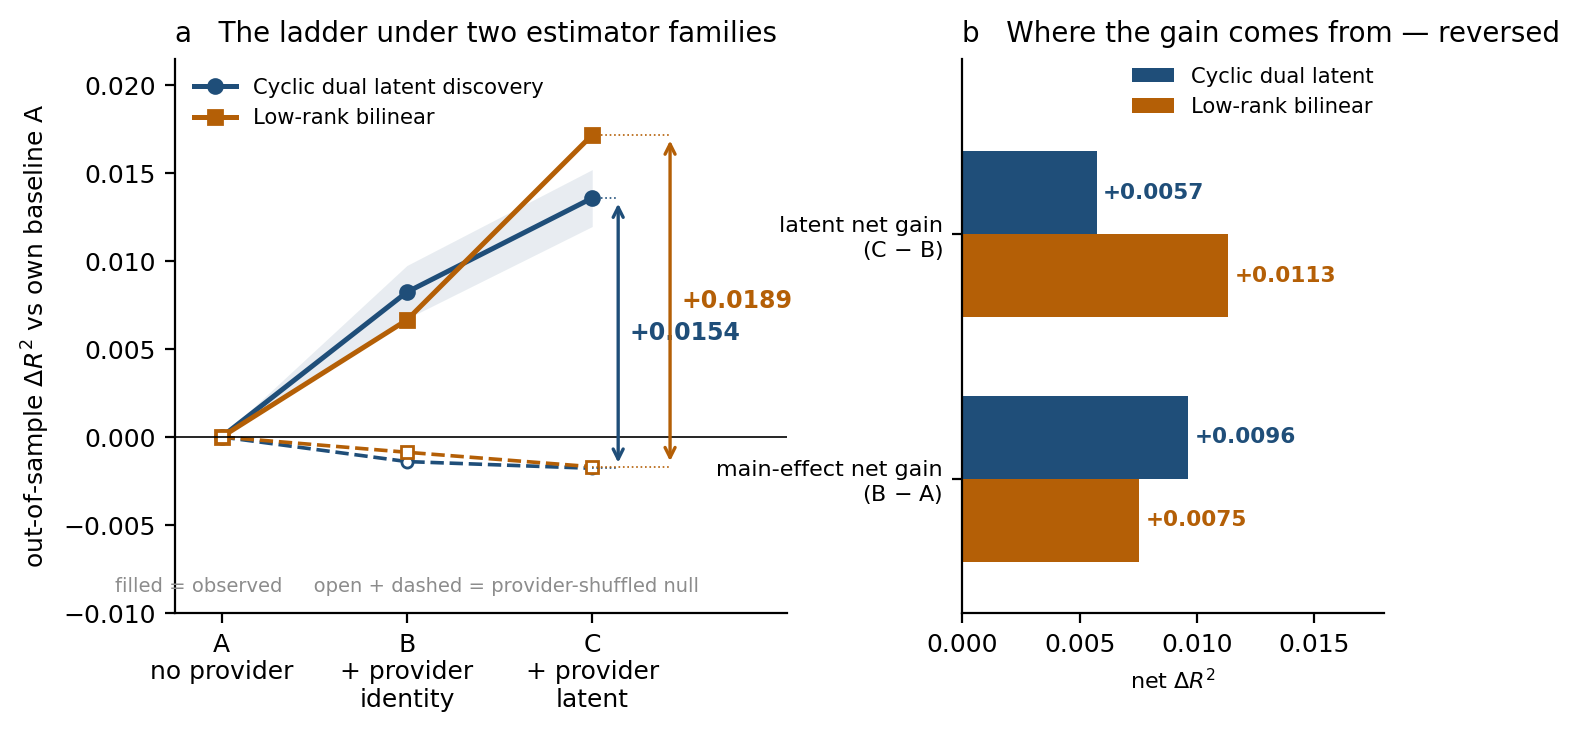

fig2_criterion_flips.png


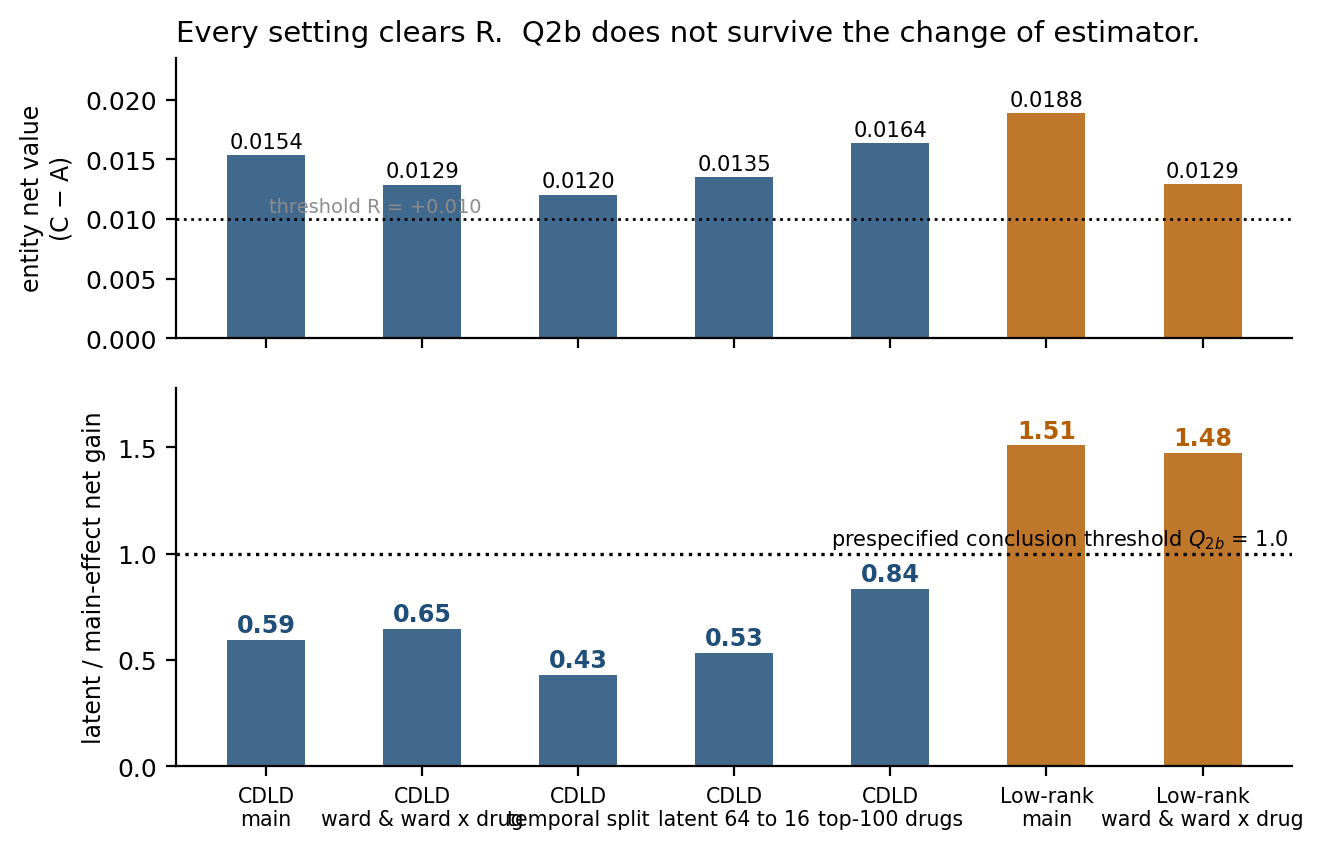

fig3_profiles_clusters.png


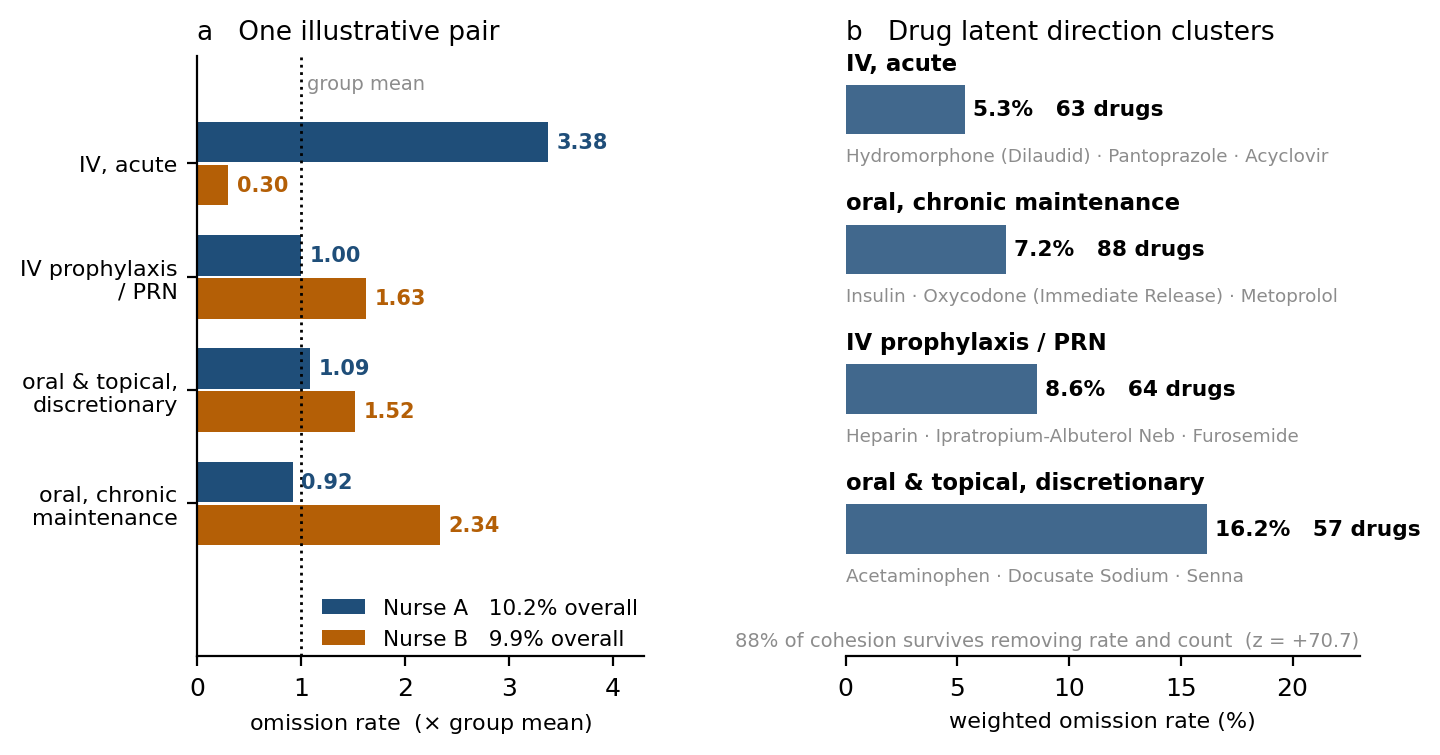

In [6]:
from IPython.display import Image, display
import os
for f in sorted(os.listdir('figures')):
    if f.endswith('.png'):
        print(f); display(Image('figures/' + f))

## 10. Independent re-check

In [7]:
import subprocess, sys
print(subprocess.run([sys.executable, 'verify.py'], capture_output=True, text=True).stdout)

verify.py - reproduce every number in the manuscript from the shipped results.

THE NULL - corrected before these runs (see notebook section 2)
------------------------------------------------------------------------------
                                design  providers_per_admission_mean  median  max  provider_events_median  provider_events_max  share_unchanged
                         observed data                          3.02       2  635                    2654                46637           1.0000
null v1 (broken: fancy-index collapse)                          1.00       1    1                    2505               182967              NaN
        null v2 (corrected, used here)                          3.02       2  635                    2754                42465           0.0026

  The first implementation collapsed every admission to one provider.
  Correcting it moved the cyclic-dual-latent estimate by 20% and the
  low-rank estimate by 2%.  Both are reported.

TABLE 2 - the

---

# v5 — the decomposition-aligned experiment

Everything above is the v4 analysis. What follows was added after an external
methodological review pointed out that, under the unconstrained readout, `B − A`
and `C − B` cannot be read as a main effect and an interaction: the one-dimensional
provider term enters the **same nonlinear head** as the drug representation and the
covariates, so stage B is not additive in the provider.

**The analysis plan for this diagnostic was frozen before any of it was run** —
see `protocol/2026-09-06_analysis_amendment_frozen.md`, which carries the
completion timestamp and the sha256 of its own body.

Provenance in this section is the same as above: cells that took hours carry the
**recorded stdout** of the actual run (the raw files are in `logs/`); cells that run
in seconds from committed result files are **executed at build time**.


## 11. The aligned estimator

The cyclic dual-latent mechanism is kept. Only the readout is constrained:

    eta_A = f(x)
    eta_B = f(x) + alpha_i
    eta_C = f(x) + alpha_i + u_i . v_j

`f(x)` is **the same network as the native A stage**, so the A rung is *shared*
between the two estimators rather than refitted — any difference further up the
ladder therefore cannot come from stochastic variation in the common baseline.

The unit tests below are what make the claim checkable: B must be exactly additive
in the provider, and C's second difference must equal the bilinear form.

In [ ]:
import sys; sys.path.insert(0, 'src')
import cdld_a
r = cdld_a.unit_tests()
print('\nverdict:', 'PASS' if (r['U1_arch_identical'] and r['U2_pass']
      and r['U3_pass'] and r['U5_pass']) else 'FAIL')

  U1_arch_identical                True
  U1_n_params_native               83219
  U1_n_params_aligned_base         83219
  U2_maxabs_D_B                    5.960464477539063e-08
  U2_pass                          True
  U3_maxabs_err                    7.152557373046875e-07
  U3_pass                          True
  U4_native_B_maxabs_D             0.00011409074068069458
  U4_native_B_sd_D                 2.3872706151450984e-05
  U5_additive_frac_inter           3.631264484350689e-32
  U5_pass                          True

verdict: PASS


## 12. Training the aligned ladder

30 units (B and C × 3 arms × 5 folds); the A rung is shared, so it costs nothing.
The first run is kept in the repository because it **failed the prespecified fit
gate** — and the reason it failed is itself a result (§14).

In [ ]:
!python src/run_cdld_a.py     # run 1 — nominal hyperparameters

  A 공유 완료 (5겹, 계산 0)
  ✓ CDLD-A base_real_f0_B  BSS +0.14115  AUC 0.7847  295s
  ✓ CDLD-A base_real_f1_B  BSS +0.14195  AUC 0.7891  316s
  ✓ CDLD-A base_real_f2_B  BSS +0.14477  AUC 0.7881  289s
  ✓ CDLD-A base_real_f3_B  BSS +0.13578  AUC 0.7827  290s
  ✓ CDLD-A base_real_f4_B  BSS +0.13782  AUC 0.7819  301s
  ✓ CDLD-A base_shuffle0_f0_B  BSS +0.13689  AUC 0.7794  304s
  ✓ CDLD-A base_shuffle0_f1_B  BSS +0.13670  AUC 0.7825  300s
  ✓ CDLD-A base_shuffle0_f2_B  BSS +0.14050  AUC 0.7829  302s
  ✓ CDLD-A base_shuffle0_f3_B  BSS +0.13118  AUC 0.7768  285s
  ✓ CDLD-A base_shuffle0_f4_B  BSS +0.13368  AUC 0.7765  288s
  ✓ CDLD-A base_shuffle1_f0_B  BSS +0.13719  AUC 0.7796  304s
  ✓ CDLD-A base_shuffle1_f1_B  BSS +0.13683  AUC 0.7828  300s
  ✓ CDLD-A base_shuffle1_f2_B  BSS +0.14034  AUC 0.7827  296s
  ✓ CDLD-A base_shuffle1_f3_B  BSS +0.13100  AUC 0.7767  284s
  ✓ CDLD-A base_shuffle1_f4_B  BSS +0.13357  AUC 0.7764  296s
  ✓ CDLD-A base_real_f0_C  BSS +0.14267  AUC 0.7861  314s
  ✓ CDLD-A 

In [ ]:
!python src/run_cdld_a2.py    # run 2 — latent tables excluded from L2

  A 공유 완료 (5겹, 계산 0)
  ✓ CDLD-A2 base_real_f0_C  BSS +0.15052  AUC 0.7937  275s
  ✓ CDLD-A2 base_real_f1_C  BSS +0.15399  AUC 0.7983  313s
  ✓ CDLD-A2 base_real_f2_C  BSS +0.15417  AUC 0.7967  306s
  ✓ CDLD-A2 base_real_f3_C  BSS +0.14575  AUC 0.7913  307s
  ✓ CDLD-A2 base_real_f4_C  BSS +0.14710  AUC 0.7937  308s
  ✓ CDLD-A2 base_shuffle0_f0_C  BSS +0.13564  AUC 0.7779  307s
  ✓ CDLD-A2 base_shuffle0_f1_C  BSS +0.13718  AUC 0.7810  313s
  ✓ CDLD-A2 base_shuffle0_f2_C  BSS +0.13960  AUC 0.7813  318s
  ✓ CDLD-A2 base_shuffle0_f3_C  BSS +0.13106  AUC 0.7758  310s
  ✓ CDLD-A2 base_shuffle0_f4_C  BSS +0.13269  AUC 0.7779  307s
  ✓ CDLD-A2 base_shuffle1_f0_C  BSS +0.13585  AUC 0.7781  310s
  ✓ CDLD-A2 base_shuffle1_f1_C  BSS +0.13739  AUC 0.7815  313s
  ✓ CDLD-A2 base_shuffle1_f2_C  BSS +0.13936  AUC 0.7811  305s
  ✓ CDLD-A2 base_shuffle1_f3_C  BSS +0.13111  AUC 0.7759  304s
  ✓ CDLD-A2 base_shuffle1_f4_C  BSS +0.13255  AUC 0.7778  307s

[CDLD-A] 이번 호출 15건 · 남은 0건 / 전체 15건


In [ ]:
!python src/run_cdld_a2_ward.py   # ward and ward-by-drug controlled

  A 공유 완료 (5겹, 계산 0)
  ✓ CDLD-A2 wardX_real_f0_B  BSS +0.14583  AUC 0.7900  358s
  ✓ CDLD-A2 wardX_real_f1_B  BSS +0.14940  AUC 0.7939  366s
  ✓ CDLD-A2 wardX_real_f2_B  BSS +0.14878  AUC 0.7932  363s
  ✓ CDLD-A2 wardX_real_f3_B  BSS +0.14067  AUC 0.7881  354s
  ✓ CDLD-A2 wardX_real_f4_B  BSS +0.14327  AUC 0.7905  341s
  ✓ CDLD-A2 wardX_shuffle0_f0_B  BSS +0.14196  AUC 0.7860  355s
  ✓ CDLD-A2 wardX_shuffle0_f1_B  BSS +0.14495  AUC 0.7892  373s
  ✓ CDLD-A2 wardX_shuffle0_f2_B  BSS +0.14553  AUC 0.7889  358s
  ✓ CDLD-A2 wardX_shuffle0_f3_B  BSS +0.13689  AUC 0.7839  360s
  ✓ CDLD-A2 wardX_shuffle0_f4_B  BSS +0.13977  AUC 0.7866  375s
  ✓ CDLD-A2 wardX_shuffle1_f0_B  BSS +0.14225  AUC 0.7861  354s
  ✓ CDLD-A2 wardX_shuffle1_f1_B  BSS +0.14512  AUC 0.7895  362s
  ✓ CDLD-A2 wardX_shuffle1_f2_B  BSS +0.14484  AUC 0.7890  359s
  ✓ CDLD-A2 wardX_shuffle1_f3_B  BSS +0.13680  AUC 0.7838  343s
  ✓ CDLD-A2 wardX_shuffle1_f4_B  BSS +0.13970  AUC 0.7866  379s
  ✓ CDLD-A2 wardX_real_f0_C  BSS +0.152

## 13. Adjudication

`gamma*` is the null-adjusted B-stage gap; `kappa` is the shift in the total
provider-inclusion effect. With A shared these two determine the ratio exactly, so
the relation below is an **identity**, not a fitted model — which is why it is used
for attribution rather than for prediction.

In [ ]:
import sys, subprocess
print(subprocess.run([sys.executable, 'src/adj_a2.py'],
                     capture_output=True, text=True).stdout)

CDLD-A2 완료 단위 30/30 (B,C x 3팔 x 5겹)

native (귀무 3, 발표)      A 0.13608  B 0.14431  C 0.14965  | main +0.00963  latent +0.00573  total +0.01535  비 0.5947
native (귀무 2, 정합)      A 0.13608  B 0.14431  C 0.14965  | main +0.00961  latent +0.00565  total +0.01526  비 0.5884
CDLD-A2 (귀무 2)         A 0.13608  B 0.14029  C 0.15031  | main +0.00451  latent +0.01056  total +0.01506  비 2.3433

gamma*  = +0.00510   (native B - CDLD-A2 B, 귀무 보정)
kappa   = -0.00020   (총 포함 효과 이동)
항등식 검산 : Delta_latent,A 관측 +0.01056 vs l+g+k +0.01056  오차 +0.00e+00

== 귀속 분해 ==
  r_native 0.5884 -> r_aligned 2.3433   (dr +1.7549)
  readout 제약 몫  r(g,0)=2.3871   기여 +1.7987  (+102%)
  총신호 이동 몫   r(0,k)=0.5678   기여 -0.0205  (-1%)
  잔차(교호)                        -0.0232  (-1%)

== 판정 ==
  R (Delta_total,A) +0.01506  vs 기준 +0.0100  -> 유지
  kappa 임계 -0.00526 -> kappa -0.00020 안전
  Q2b(CDLD-A) 비 2.3433 vs 1.0 -> 통과
  C 단계 BSS  native 0.14965  CDLD-A2 0.15031  차 +0.00065  (관문 margin -0.0025)  -> 점추정 통과 (부트스트랩 CI 로 확정)



The counterfactual decomposition of the ratio shift, fixed in the
protocol before the run: how much is explained by the readout constraint alone
(`kappa = 0`), how much by the shift in total signal alone (`gamma* = 0`), and how
much is residual.

In [ ]:
import json
a = json.load(open('results/v5/adj_a2.json'))
dr = a['dr']
print(f"r  {a['r_nat']:.4f}  ->  {a['r_A']:.4f}    (dr {dr:+.4f})")
for k, lab in (('share_readout','readout constraint'), ('share_kappa','total-signal shift'),
               ('resid','residual')):
    print(f"  {lab:22s} {a[k]:+.4f}   {a[k]/dr*100:+6.0f}%")
print(f"\ngamma* {a['gamma']:+.5f}   kappa {a['kappa']:+.5f}")

r  0.5884  ->  2.3433    (dr +1.7549)
  readout constraint     +1.7987     +102%
  total-signal shift     -0.0205       -1%
  residual               -0.0232       -1%

gamma* +0.00510   kappa -0.00020


## 14. Why run 1 failed — nominal vs effective regularisation

The bilinear term goes straight into the logit, so `weight_decay` acts on it very
differently than it does on a latent table that is followed by a `BatchNorm`. With
Adam, once the data gradient on a cold-start bilinear term is small, the decay term
dominates the gradient and the normalisation pushes the table toward zero at the
full learning rate every step.

In [ ]:
import json
n = json.load(open('results/v5/latent_norms.json'))
print('%-22s %9s %9s %13s %14s' % ('', '||u||', '||v||', 'sd(u.v)', 'sd(alpha)'))
for k in ('at_initialisation', 'run1_L2_on_latent', 'run2_L2_excluded'):
    r = n[k]
    print('%-22s %9.4f %9.4f %13s %14s' % (
        k, r['u_norm'], r['v_norm'],
        f"{r['sd_uv_logit']:.4f}" if 'sd_uv_logit' in r else '-',
        f"{r['sd_alpha_logit']:.4f}" if 'sd_alpha_logit' in r else '-'))
print('\nrun 1: the interaction term contributes sd 0.0018 on the logit scale —')
print('       2% of the main effect. The table collapsed by a factor of ~20-40.')
print('run 2: identical architecture, identical schedule, identical seed;')
print('       only the two latent tables are excluded from weight decay.')

                           ||u||     ||v||       sd(u.v)      sd(alpha)
at_initialisation         0.8000    0.8000             -              -
run1_L2_on_latent         0.0385    0.0213        0.0018         0.0973
run2_L2_excluded          1.0079    0.9634        0.1699         0.0782

run 1: the interaction term contributes sd 0.0018 on the logit scale —
       2% of the main effect. The table collapsed by a factor of ~20-40.
run 2: identical architecture, identical schedule, identical seed;
       only the two latent tables are excluded from weight decay.


## 15. Skill decomposition vs function decomposition

This is the part that answers the question the review raised. The decomposition of
*predictive skill* differs by a factor of four between the two models. The
decomposition of the *fitted function* — same grid, same fixed context, same
weighting, same code — differs by a factor of 1.4, **and the ordering reverses.**

In [ ]:
import json
F = json.load(open('results/v5/fn_decomp.json'))
A = json.load(open('results/v5/adj_a2.json'))
print('%-14s %14s %16s' % ('', 'skill (Q2b)', 'function Var(c)/Var(a)'))
print('%-14s %14.2f %16.2f' % ('native CDLD', A['native2']['ratio'], F['native_C']['inter_over_provider']))
print('%-14s %14.2f %16.2f' % ('CDLD-A', A['aligned']['ratio'], F['cdldA2_C']['inter_over_provider']))
print('%-14s %14.1fx %15.1fx' % ('ratio of the two',
      A['aligned']['ratio']/A['native2']['ratio'],
      F['native_C']['inter_over_provider']/F['cdldA2_C']['inter_over_provider']))

                  skill (Q2b) function Var(c)/Var(a)
native CDLD              0.59             0.74
CDLD-A                   2.34             0.53
ratio of the two            4.0x             1.4x


## 16. The nine settings, stratified by readout

Not by setting — by whether the readout implements the decomposition. Read this way,
`R` holds everywhere and `Q2b` splits exactly along the readout, not along the
estimator family.

In [ ]:
import pandas as pd
t = pd.read_csv('results/v5/table1_ladders.csv')
print(t[['설정','d_main','d_latent','d_total','ratio','R기준','Q2','Q2b','S기준']]
      .to_string(index=False))

                    설정  d_main  d_latent  d_total   ratio R기준  Q2 Q2b S기준
    순환 이중 잠재 (비제약 읽기층) 0.00963   0.00573  0.01535 0.59474  충족  충족 미충족  충족
      순환 이중 잠재 — 병동 통제 0.00781   0.00504  0.01286 0.64552  충족  충족 미충족  충족
  순환 이중 잠재 (귀무2, 정합비교) 0.00961   0.00565  0.01526 0.58837  충족  충족 미충족  충족
분해 정합 변종 CDLD-A 1차(붕괴) 0.00451   0.00100  0.00550 0.22143 미충족 미충족 미충족 미충족
       분해 정합 변종 CDLD-A 0.00451   0.01056  0.01506 2.34330  충족  충족  충족  충족
      분해 정합 변종 — 병동 통제 0.00381   0.00776  0.01157 2.03776  충족  충족  충족  충족
              저랭크 이중선형 0.00751   0.01134  0.01885 1.50890  충족  충족  충족  충족
      저랭크 이중선형 — 병동 통제 0.00522   0.00770  0.01293 1.47520  충족  충족  충족  충족


## 17. Independent re-check of every v5 number

In [ ]:
import subprocess, sys
r = subprocess.run([sys.executable, 'src/verify_v5.py'], capture_output=True, text=True)
print(r.stdout[-4000:]); print('exit', r.returncode)

== 사다리 ==
OK   native  Delta_total (R)                              got +0.01535  want +0.01535
OK   native  Delta_main                                   got +0.00963  want +0.00963
OK   native  Delta_latent                                 got +0.00573  want +0.00573
OK   native  ratio (Q2b)                                  got +0.59474  want +0.59474
OK   native  S                                            got -0.00038  want -0.00038
OK   native ward Delta_total                              got +0.01286  want +0.01286
OK   CDLD-A2 Delta_total (R)                              got +0.01506  want +0.01506
OK   CDLD-A2 Delta_main                                   got +0.00451  want +0.00451
OK   CDLD-A2 Delta_latent                                 got +0.01056  want +0.01056
OK   CDLD-A2 ratio (Q2b)                                  got +2.34330  want +2.34330
OK   CDLD-A2 S                                            got -0.00054  want -0.00054
OK   CDLD-A 1차 Delta_total (붕괴)             

---

# v6 — separating the readout from the regularisation

External review of v5 raised the decisive objection: the aligned model's success was
obtained **after seeing the first run fail**, by removing weight decay from the latent
tables. So the observed shift could be the explicit decomposition, or it could be a
regularisation that happens to favour a bilinear interaction term.

This section crosses the two factors. **The plan — including the decision rule and what
would be concluded under each outcome — was frozen before the run**
(`protocol/2026-09-06_second_amendment_frozen.md`, timestamp and sha256 inside).

The first amendment had no contingency clause for a failed fit gate at all; that is
recorded as a deviation rather than described as a pre-recorded remedy.

In [ ]:
!python src/run_nat_nodecay.py   # unconstrained readout, latent L2 = 0
!python src/run_a2_mid.py        # aligned readout, latent L2 = 1e-5
!python src/run_seed.py          # seed replication of the B stage

  A 공유 완료 (5겹, 계산 0)
  ✓ natND base_real_f0_C  BSS +0.14857  AUC 0.7927  438s
  ✓ natND base_real_f1_C  BSS +0.15394  AUC 0.7977  431s
  ✓ natND base_real_f2_C  BSS +0.15203  AUC 0.7952  423s
  ✓ natND base_real_f3_C  BSS +0.14337  AUC 0.7903  411s
  ✓ natND base_real_f4_C  BSS +0.14688  AUC 0.7942  434s
  ✓ natND base_shuffle0_f0_C  BSS +0.13551  AUC 0.7774  412s
  ✓ natND base_shuffle0_f1_C  BSS +0.13749  AUC 0.7798  423s
  ✓ natND base_shuffle0_f2_C  BSS +0.13986  AUC 0.7808  412s
  ✓ natND base_shuffle0_f3_C  BSS +0.12955  AUC 0.7744  407s
  ✓ natND base_shuffle0_f4_C  BSS +0.13246  AUC 0.7766  422s
  ✓ natND base_shuffle1_f0_C  BSS +0.13525  AUC 0.7774  442s
  ✓ natND base_shuffle1_f1_C  BSS +0.13710  AUC 0.7807  432s
  ✓ natND base_shuffle1_f2_C  BSS +0.13917  AUC 0.7802  413s
  ✓ natND base_shuffle1_f3_C  BSS +0.12976  AUC 0.7746  404s
  ✓ natND base_shuffle1_f4_C  BSS +0.13311  AUC 0.7773  420s

[CDLD-A] 이번 호출 15건 · 남은 0건 / 전체 15건
  A 공유 완료 (5겹, 계산 0)
  ✓ A2mid base_real_f0_C  

In [ ]:
!python src/run_a2_null3.py      # aligned, third null replicate

  A 공유 완료 (5겹, 계산 0)
  ✓ A2n3 base_shuffle2_f0_B  BSS +0.13707  AUC 0.7799  322s
  ✓ A2n3 base_shuffle2_f1_B  BSS +0.13855  AUC 0.7830  336s
  ✓ A2n3 base_shuffle2_f2_B  BSS +0.14146  AUC 0.7830  344s
  ✓ A2n3 base_shuffle2_f3_B  BSS +0.13144  AUC 0.7769  343s
  ✓ A2n3 base_shuffle2_f4_B  BSS +0.13274  AUC 0.7786  344s
  ✓ A2n3 base_shuffle2_f0_C  BSS +0.13528  AUC 0.7783  363s
  ✓ A2n3 base_shuffle2_f1_C  BSS +0.13740  AUC 0.7813  358s
  ✓ A2n3 base_shuffle2_f2_C  BSS +0.13945  AUC 0.7814  354s
  ✓ A2n3 base_shuffle2_f3_C  BSS +0.13111  AUC 0.7761  348s
  ✓ A2n3 base_shuffle2_f4_C  BSS +0.13285  AUC 0.7774  350s

[CDLD-A] 이번 호출 10건 · 남은 0건 / 전체 10건


## 18. The 2×2

The unconstrained readout does not cross 1 at either regularisation setting; the aligned
readout crosses it at both settings where the model fits. The magnitude of the ratio is
itself sensitive to regularisation, which is why the claim is about the direction of the
verdict rather than about the number.

In [ ]:
import pandas as pd
t = pd.read_csv('results/v6/table1_ladders_v6.csv')
print(t[['설정','readout','latent_L2','n_null','d_main','d_latent','d_total','ratio','S']]
      .to_string(index=False))

                    설정 readout latent_L2  n_null  d_main  d_latent  d_total   ratio        S
     순환 이중 잠재 (native)     비제약      1e-4       3 0.00963   0.00573  0.01535 0.59474 -0.00038
    native — 잠재표 감쇠 제외     비제약         0       2 0.00961   0.00443  0.01403 0.46089  0.00022
        CDLD-A 1차 (붕괴)      정합      1e-4       2 0.00451   0.00100  0.00550 0.22143  0.00058
  CDLD-A — 잠재표 L2 1e-5      정합      1e-5       2 0.00451   0.00875  0.01326 1.94322  0.00005
           CDLD-A (본판)      정합         0       3 0.00435   0.01072  0.01507 2.46427 -0.00071
        native — 병동 통제     비제약      1e-4       3 0.00781   0.00504  0.01286 0.64552 -0.00087
        CDLD-A — 병동 통제      정합         0       2 0.00381   0.00776  0.01157 2.03776 -0.00078
        저랭크 이중선형 (ALS)      정합         —       3 0.00751   0.01124  0.01875 1.49800 -0.00073
           ALS — 병동 통제      정합         —       2 0.00522   0.00770  0.01293 1.47500 -0.00169
    ALS — Hold Dose 제외      정합         —       2 0.00714   0.01132  0.

## 19. Function-level decomposition, with the prespecified metric restored

The first amendment named `Var(c)/[Var(a)+Var(b)+Var(c)]` and `sd(D)/sd(M)`; v5 headlined
`Var(c)/Var(a)` instead. That is restored here as a post-hoc secondary, and both give the
same ordering and the same reversal.

The last two rows are the point of the section: the raw grids correlate at 0.96 because
over 90% of the grid variance is the drug main effect. The **interaction components**
correlate at 0.50. The two models found interaction of comparable magnitude, but only
half-shared in structure — so "they learned similar functions" is withdrawn.

In [ ]:
import json
F = json.load(open('results/v6/fn_decomp2.json'))
def row(k, lab):
    s = F[k]
    print('%-32s %7.4f  median %7.4f  IQR [%.4f, %.4f]' %
          (lab, s['mean'], s['median'], s['q25'], s['q75']))
print('-- prespecified primary --')
row('native_frac_inter','native   frac_inter'); row('aligned_frac_inter','CDLD-A   frac_inter')
row('native_sdD_sdM','native   sd(D)/sd(M)');   row('aligned_sdD_sdM','CDLD-A   sd(D)/sd(M)')
print('-- post-hoc secondary --')
row('native_inter_over_prov','native   Var(c)/Var(a)'); row('aligned_inter_over_prov','CDLD-A   Var(c)/Var(a)')
print('-- do they find the same interaction? --')
row('corr_c','corr(c_native, c_aligned)'); row('corr_eta_raw','corr(eta, eta)  [not used]')

-- prespecified primary --
native   frac_inter               0.0422  median  0.0418  IQR [0.0383, 0.0457]
CDLD-A   frac_inter               0.0232  median  0.0225  IQR [0.0200, 0.0263]
native   sd(D)/sd(M)              1.5156  median  1.5088  IQR [1.3693, 1.6194]
CDLD-A   sd(D)/sd(M)              1.3610  median  1.3873  IQR [1.3559, 1.3998]
-- post-hoc secondary --
native   Var(c)/Var(a)            0.7837  median  0.7543  IQR [0.5921, 0.9142]
CDLD-A   Var(c)/Var(a)            0.5283  median  0.5398  IQR [0.5116, 0.5603]
-- do they find the same interaction? --
corr(c_native, c_aligned)         0.4980  median  0.5022  IQR [0.4839, 0.5161]
corr(eta, eta)  [not used]        0.9643  median  0.9689  IQR [0.9594, 0.9729]


## 20. The null preserves the mean exactly and the distribution only approximately

Reported as a correction: the manuscript previously said the provider frequency
distribution was preserved. The mean is exact by construction and the rank order is
nearly so, but the tails compress — and the minimum falls below the cohort's own
inclusion threshold of 200 events per provider.

In [ ]:
import pandas as pd
print(pd.read_csv('results/v6/table8_null_frequency.csv').to_string(index=False))

  팔     중앙        평균    최대  최소   순위상관
 실제 2653.5 4660.8419 46637 200    NaN
귀무0 2754.0 4660.8419 42465  99 0.9914
귀무1 2723.5 4660.8419 42833  94 0.9901
귀무2 2691.0 4660.8419 41481 108 0.9907


## 21. Independent re-check of every v6 number

`verify_v6.py` reads only committed result files. Besides recomputing the reported
values it asserts the **frozen decision rule** — so if the thresholds were moved after
the fact, this script fails.

In [ ]:
import subprocess, sys
r = subprocess.run([sys.executable, 'src/verify_v6.py'], capture_output=True, text=True)
print(r.stdout[-4500:]); print('exit', r.returncode)

== 사다리 (귀무 3회, 본문 headline) ==
OK   native  Delta_main                             got +0.00963  want +0.00963
OK   native  Delta_latent                           got +0.00573  want +0.00573
OK   native  Delta_total (R)                        got +0.01535  want +0.01535
OK   native  ratio                                  got +0.59474  want +0.59470
OK   native  S                                      got -0.00038  want -0.00038
OK   CDLD-A  Delta_main                             got +0.00435  want +0.00435
OK   CDLD-A  Delta_latent                           got +0.01072  want +0.01072
OK   CDLD-A  Delta_total (R)                        got +0.01507  want +0.01507
OK   CDLD-A  ratio                                  got +2.46427  want +2.46430
OK   CDLD-A  S                                      got -0.00071  want -0.00071

== A 공유 · 항등식 ==
OK   A_native == A_CDLD-A                           got +0.00000  want +0.00000
OK   gamma* (3-null)                                got +0.00528  want 

---

# v7 — the alternative null, run to completion

The second frozen amendment promised the alternative null's **performance**, not just its
design. v6 shipped the design and no numbers. This section closes that.

## 22. The alternative null, measured

It swaps whole admissions between providers within strata of (rows, distinct providers).
It preserves *more* structure than the primary null — which sounds better until you
measure how much permutation is left.


In [ ]:
import json, csv, numpy as np
AR = {}
for r in csv.DictReader(open('results/v7/table10_alt_null_arms.csv')):
    AR[r['arm']] = {k: float(r[k]) for k in 'ABC'}
def ladder(nulls):
    b, c = AR['real']['B'], AR['real']['C']
    bn = np.mean([AR[x]['B'] for x in nulls]); cn = np.mean([AR[x]['C'] for x in nulls])
    dm, dt = b - bn, c - cn
    return dict(main=dm, latent=dt-dm, total=dt, ratio=(dt-dm)/dm, S=cn-bn,
                B_null=bn, C_null=cn)
primary = ladder(['shuffle0','shuffle1','shuffle2'])
alt     = ladder(['blockswap0','blockswap1'])
print(f'{"":34}{"main":>9}{"latent":>9}{"R":>9}{"ratio":>8}{"S":>10}')
for nm, d in (('primary  per-admission relabel', primary),
              ('alternative  block swap', alt)):
    print(f'{nm:34}{d["main"]:>+9.4f}{d["latent"]:>+9.4f}{d["total"]:>+9.4f}'
          f'{d["ratio"]:>8.2f}{d["S"]:>+10.4f}')
print()
print(f'  R  >= +0.010 :  primary {primary["total"]>=.010}   alternative {alt["total"]>=.010}')
print(f'  Q2b >= 1.0   :  primary {primary["ratio"]>=1.0}   alternative {alt["ratio"]>=1.0}')
print(f'  S  <= 0      :  primary {primary["S"]<=0}   alternative {alt["S"]<=0}   <-- the alternative FAILS')
print()
print('  the null reference lines sit HIGHER under the alternative null:')
print(f'    B_null {primary["B_null"]:.5f} -> {alt["B_null"]:.5f}')
print(f'    C_null {primary["C_null"]:.5f} -> {alt["C_null"]:.5f}')
print('  i.e. the null arm fits too well - residual provider structure survives the swap.')


                                       main   latent        R   ratio         S
primary  per-admission relabel      +0.0075  +0.0112  +0.0188    1.50   -0.0007
alternative  block swap             +0.0065  +0.0092  +0.0157    1.41   +0.0014

  R  >= +0.010 :  primary True   alternative True
  Q2b >= 1.0   :  primary True   alternative True
  S  <= 0      :  primary True   alternative False   <-- the alternative FAILS

  the null reference lines sit HIGHER under the alternative null:
    B_null 0.12775 -> 0.12874
    C_null 0.12702 -> 0.13010
  i.e. the null arm fits too well - residual provider structure survives the swap.


## 23. Why the block swap is the *weaker* permutation

Not an assertion — the runner prints it. Only **1.6%** of admissions come back unswapped,
but **31.7% of rows keep their original provider**, because a high-volume provider mostly
finds swap partners among their *own* other admissions inside the same size stratum.

That is why `S` turns positive. And it is why the primary null stays primary — a
justification we can only offer **post hoc**, having run both. Neither is a perfect null.


In [ ]:
print(open('logs/v7_bg_blockswap.log').read().strip()[-1150:])


] 4,362,548행 · 간호사 936 x 약물 522 · 셀 106,580 · 밀도 21.81% · 유효표본 15,908
  누락률 9.29%  (28s)

  [null_B seed 90] 입원 158,422 중 «원배정 그대로» 1.6% · 행 일치 31.6%
  blockswap0       A +0.1286 · B +0.1287 · C +0.1301   (주효과 +0.0001 · 잠재 +0.0014)  reliability/1/r20

[none] 순가치 — 주효과 +0.0075 · 잠재 +0.0113 · 총 +0.0189
  S  건전성  섞기 잠재 -0.0008 <= 0  통과
  R  필수    총 +0.0189 >= +0.010  통과
  Q2 핵심    잠재 +0.0113 >= +0.005  통과
  Q2b 핵심   잠재/주효과 1.51 >= 1.0  통과

저장: results/07_사전등록_none.csv  (357s)
[none] 캐시 사용 4,362,548행
[none] 4,362,548행 · 간호사 936 x 약물 522 · 셀 106,580 · 밀도 21.81% · 유효표본 15,908
  누락률 9.29%  (8s)

  [null_B seed 91] 입원 158,422 중 «원배정 그대로» 1.6% · 행 일치 31.8%
  blockswap1       A +0.1286 · B +0.1288 · C +0.1302   (주효과 +0.0002 · 잠재 +0.0014)  reliability/1/r20

[none] 순가치 — 주효과 +0.0075 · 잠재 +0.0113 · 총 +0.0189
  S  건전성  섞기 잠재 -0.0008 <= 0  통과
  R  필수    총 +0.0189 >= +0.010  통과
  Q2 핵심    잠재 +0.0113 >= +0.005  통과
  Q2b 핵심   잠재/주효과 1.51 >= 1.0  통과

저장: results/07_사전등록_none.csv  (336s)
=== 대안 귀무 완료 ===

## 24. Independent re-check of every v7 number

`src/verify_v7.py` rebuilds the alternative-null ladder from the arm-level file, rebuilds
all five cells of the 2×2 from the per-fold results, re-derives the `gamma*`/`kappa`
identity under **both** null counts, and asserts the direction of every claim made above.

It is split into two tiers. Tier 1 touches only committed CSV/JSON. Tier 2 recomputes the
null's frequency distribution from the MIMIC-derived cache and **skips** — without changing
the exit code — when that cache is absent. The transcript below is the run with the cache
moved out of the way, which is the run a reader of this repository can reproduce.

(The manuscript-text block also skips unless the manuscript file sits alongside the repo.)


In [ ]:
import subprocess, sys
r = subprocess.run([sys.executable, 'src/verify_v7.py'], capture_output=True, text=True)
print(r.stdout[-3200:]); print('exit code:', r.returncode)


에서 유지 · S 는 대안 귀무에서만 양수 (§4.11.1)

== ★2x2 배포 표 (table11) 가 겹 단위 결과와 일치하는가 ==
OK   table11 비제약/1e-4 d_main                        got +0.00961  want +0.00961
OK   table11 비제약/1e-4 d_latent                      got +0.00565  want +0.00565
OK   table11 비제약/1e-4 d_total                       got +0.01526  want +0.01526
OK   table11 비제약/1e-4 ratio                         got +0.58837  want +0.58800
OK   table11 비제약/1e-4 S                             got -0.00031  want -0.00031
OK   table11 비제약/0 d_main                           got +0.00961  want +0.00961
OK   table11 비제약/0 d_latent                         got +0.00443  want +0.00443
OK   table11 비제약/0 d_total                          got +0.01403  want +0.01403
OK   table11 비제약/0 ratio                            got +0.46089  want +0.46100
OK   table11 비제약/0 S                                got +0.00022  want +0.00022
OK   table11 정합/1e-4 d_main                         got +0.00451  want +0.00451
OK   table11 정합/1e-4 d_latent             

---

# v8 — two corrections that no result depended on

Neither of these changes a number in the ladder. Both were wrong anyway.

## 25. The alternative null's permutation strength — a counter that measured the wrong thing

v6 said *32% of admissions came back unswapped*; the unit was wrong. v7 corrected it to
1.6% — but that figure comes from a counter that only asks whether a stratum **had** an
exchange partner. A random permutation of a size-2 stratum is the identity half the time,
so admissions that came back unchanged *despite* having a partner were never counted.


In [ ]:
import csv
for r in csv.DictReader(open('results/v7/table12_null_B_diag.csv')):
    print(f"seed {r['seed']}  |  no eligible partner {float(r['상대없는층_비율']):6.2%}"
          f"   ACTUALLY unchanged {float(r['★실제동일_비율']):6.2%}"
          f"   rows keeping provider {float(r['행_제공자유지']):6.2%}")
print()
print("  1.6%  = admissions in a stratum with no eligible exchange partner")
print("  3.5%  = admissions whose provider vector is actually unchanged   <- the number to report")
print(" 31.7%  = rows retaining the original provider identity")
print()
print("The correction makes the 'weaker null' case STRONGER, which is not a reason to")
print("have delayed it. src/diag_null_B.py recomputes all three; verify_v8.py asserts")
print("that the second exceeds the first, so they cannot be conflated again.")


seed 90  |  no eligible partner  1.62%   ACTUALLY unchanged  3.51%   rows keeping provider 31.65%
seed 91  |  no eligible partner  1.62%   ACTUALLY unchanged  3.49%   rows keeping provider 31.75%

  1.6%  = admissions in a stratum with no eligible exchange partner
  3.5%  = admissions whose provider vector is actually unchanged   <- the number to report
 31.7%  = rows retaining the original provider identity

The correction makes the 'weaker null' case STRONGER, which is not a reason to
have delayed it. src/diag_null_B.py recomputes all three; verify_v8.py asserts
that the second exceeds the first, so they cannot be conflated again.


## 26. Matching the null counts — the same mistake, one table over

Figure 3 was fixed in v7 for mixing a 3-null value into four 2-null cells. `table10` had
exactly the same problem and was missed: it put the 3-null primary next to the 2-null
alternative. Matched, the comparison is unchanged in direction — which is why this is a
reporting-honesty fix, not a result.


In [ ]:
import csv
rows=list(csv.DictReader(open('results/v7/table10_alt_null.csv')))
print(f"{'null design':38}{'n':>3}{'main':>9}{'latent':>9}{'R':>9}{'ratio':>8}{'S':>10}   role")
for r in rows:
    print(f"{r['귀무설계'][:36]:38}{r['n_null']:>3}{float(r['d_main']):>+9.5f}"
          f"{float(r['d_latent']):>+9.5f}{float(r['d_total']):>+9.5f}"
          f"{float(r['ratio']):>8.3f}{float(r['S']):>+10.5f}   {r['역할']}")


null design                             n     main   latent        R   ratio         S   role
주 귀무 — 입원별 제공자 라벨 재배정                   2 +0.00751 +0.01134 +0.01885   1.509  -0.00082   ★주 비교 (칸 맞춤)
대안 귀무 — 크기 층화 입원 블록 교환                  2 +0.00652 +0.00916 +0.01567   1.405  +0.00136   ★주 비교 (칸 맞춤)
주 귀무 — 입원별 제공자 라벨 재배정                   3 +0.00751 +0.01124 +0.01875   1.498  -0.00073   참조 (본문 headline)


## 27. The reproduction path, smoke-tested from a clean extraction

v7 shipped a verifier that ran anywhere and a *reproduction* path that ran only on the
development machine. Three scripts failed on a fresh `tar xzf`: `run_prereg.py` and
`run_ward.py` imported `nd_core` (this repository calls it `als_core`), and `figs_v7.py`
wrote to an absolute path from the development container — so it appeared to succeed
there and failed everywhere else.

Thirteen more crashed with `AttributeError` rather than saying what was missing, because
`data.prep(None)` returned `None` when its cache was absent. `tools/smoke_test.sh` now
runs every documented command against a clean extraction with no MIMIC-IV data, and the
transcript is committed at `logs/v8_smoke_test.txt`.


In [ ]:
print(open('logs/v8_smoke_test.txt').read())


# v8 재현 경로 smoke test — «자료 없는» 깨끗한 압축해제에서 실행
# 2026-09-08T01:00:05Z
# $ tar xzf repo_v8.tgz && cd repo_v2 && bash tools/smoke_test.sh

=== 자료 없이 통과해야 하는 것 ===
python3 verify.py                             OK   (exit 0)
python3 src/verify_v5.py                      OK   (exit 0)
python3 src/verify_v6.py                      OK   (exit 0)
python3 src/verify_v8.py                      OK   (exit 0)
python3 src/figs_v6.py                        OK   (exit 0)
python3 src/figs_v8.py                        OK   (exit 0)
python3 src/cdld_a.py                         OK   (exit 0)

=== 자료가 필요한 것 — «깨끗이» 멈춰야 한다 ===
python3 src/build_emar.py                     CLEAN STOP (usage)
python3 src/map_careunit.py                   CLEAN STOP (need_data)
python3 src/diag_null_B.py                    CLEAN STOP (need_data)
python3 src/run_prereg.py none                CLEAN STOP (need_data)
python3 src/run_ward.py                       CLEAN STOP (need_data)
python3 src/run_cdld.py 5                    